In [1]:
from typing import TypedDict

from langchain_community.document_loaders import PyPDFLoader
from langchain_text_splitters import RecursiveCharacterTextSplitter

from langchain_community.vectorstores import Chroma
from langchain_huggingface import HuggingFaceEmbeddings

from langgraph.graph import StateGraph, END

from tavily import TavilyClient

from langchain_groq import ChatGroq
import os
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="llama-3.3-70b-versatile"
)

In [4]:
loader = PyPDFLoader("docs/Autonomous Data Science Agent.pdf")
docs = loader.load()

##### Chunk Documents

In [5]:
splitter = RecursiveCharacterTextSplitter(
    chunk_size=100,
    chunk_overlap=100
)

chunks = splitter.split_documents(docs)

print(len(chunks))

1755


##### Embeddings

In [6]:
embedding_model = HuggingFaceEmbeddings(
    model_name="sentence-transformers/all-MiniLM-L6-v2"
)

d:\RAG\rag_venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 6184.08it/s]


##### Vector DB

In [7]:
vectorstore = Chroma(
    collection_name="crag",
    embedding_function=embedding_model
)

batch_size = 100

for i in range(0, len(chunks), batch_size):
    batch = chunks[i:i+batch_size]
    vectorstore.add_documents(batch)

print("Vector DB Created Successfully")

d:\RAG\rag_venv\lib\site-packages\langchain_core\_api\deprecation.py:141: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 0.4. An updated version of the class exists in the langchain-chroma package and should be used instead. To use it run `pip install -U langchain-chroma` and import as `from langchain_chroma import Chroma`.
  warn_deprecated(
Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


Vector DB Created Successfully


##### Retriver Node

In [8]:
def retrieve(state):
    
    query = state["query"]

    docs = vectorstore.similarity_search(
        query,
        k=5
    )

    return {
        "documents": docs
    }

##### Retrieval Evaluator

In [9]:
def evaluate_retrieval(state):

    query = state["query"]

    docs = "\n\n".join(
        [doc.page_content for doc in state["documents"]]
    )

    prompt = f"""
Question:
{query}

Retrieved Documents:
{docs}

Classify retrieval quality as:

- Correct
- Ambiguous
- Incorrect

Return ONLY one word.
"""

    response = llm.invoke(prompt)

    return {
        "label": response.content.strip()
    }

##### Quary Rewriter

In [10]:
def rewrite_query(state):

    query = state["query"]

    rewritten = f"{query} official information"

    return {
        "rewritten_query": rewritten
    }

##### Web Search

In [11]:
tavily = TavilyClient(
    api_key=os.getenv("TAVILY_API_KEY")
)

def web_search(state):

    result = tavily.search(
        state["rewritten_query"]
    )

    return {
        "web_results": result
    }

### Knowledge Refinement

##### Decompose

In [12]:
def decompose(state):

    strips = []

    for doc in state["documents"]:

        text = doc.page_content

        pieces = [
            text[i:i+150]
            for i in range(0, len(text), 150)
        ]

        strips.extend(pieces)

    return {
        "strips": strips
    }

##### Filter

In [13]:
def filter_strips(state):

    strips = state["strips"]

    filtered = strips[:5]

    return {
        "refined_context": "\n".join(filtered)
    }

##### Generator

In [14]:
def generate(state):

    query = state["query"]

    context = ""

    if state.get("refined_context"):
        context += state["refined_context"]

    if state.get("web_results"):
        context += "\n\nWeb Search Results:\n"
        context += str(state["web_results"])

    prompt = f"""
    Answer the question using the available context.

    Context:
    {context}

    Question:
    {query}
    """

    response = llm.invoke(prompt)

    return {
        "answer": response.content
    }

##### Graph

In [15]:
class GraphState(TypedDict):

    query: str

    documents: list

    label: str

    rewritten_query: str

    web_results: dict

    strips: list

    refined_context: str

    answer: str

##### Routing Logic

In [16]:
def route(state):
    
    if state["label"] == "Correct":
        return "refine"

    return "rewrite"

##### Build LangGraph

In [17]:
builder = StateGraph(GraphState)

builder.add_node("retrieve", retrieve)

builder.add_node(
    "evaluate",
    evaluate_retrieval
)

builder.add_node(
    "refine",
    decompose
)

builder.add_node(
    "rewrite",
    rewrite_query
)

builder.add_node(
    "search",
    web_search
)

builder.add_node(
    "filter",
    filter_strips
)

builder.add_node(
    "generate",
    generate
)

##### Edges

In [18]:
builder.set_entry_point("retrieve")

builder.add_edge(
    "retrieve",
    "evaluate"
)

builder.add_conditional_edges(
    "evaluate",
    route,
    {
        "refine": "refine",
        "rewrite": "rewrite"
    }
)

builder.add_edge(
    "refine",
    "filter"
)

builder.add_edge(
    "filter",
    "generate"
)

builder.add_edge(
    "rewrite",
    "search"
)

builder.add_edge(
    "search",
    "generate"
)

builder.add_edge(
    "generate",
    END
)

In [19]:
graph = builder.compile()

In [22]:
result = graph.invoke(
    {
        "query": "What is Information-Theoretic Interpretation of the Optimization Objective ?"
    }
)

print(result["answer"])

The Information-Theoretic Interpretation of the Optimization Objective is equivalent to solving the Information Bottleneck objective.


In [ ]:
result = graph.invoke(
    {
        "query": "What is the hyperparameter tuning"
    }
)

print(result["answer"])

Hyperparameter tuning is the process of selecting the optimal values for a machine learning model's hyperparameters. Hyperparameters are configuration variables that data scientists set ahead of time to manage the training process of a machine learning model. The goal of hyperparameter tuning is to find the best combination of hyperparameters that results in the best performance of the model, as measured by a specific metric. This process is critical to the performance of the model, as hyperparameters govern its learning process. Techniques for hyperparameter tuning include grid search, random search, and Bayesian optimization, among others.


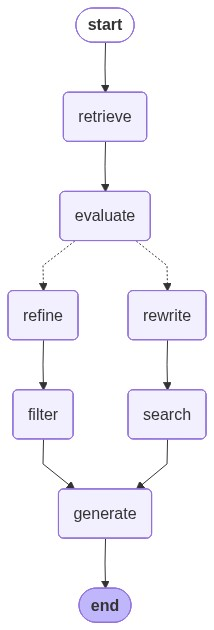

In [25]:
from IPython.display import display, Image

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)